In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt

2026-04-29 19:18:32.722935: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(X_test.shape[0], "test samples")

N_train = int(0.9 * len(X_train))
X_train, X_val = X_train[:N_train], X_train[N_train:]
y_train, y_val = y_train[:N_train], y_train[N_train:]

# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)
y_val = keras.utils.to_categorical(y_val, 10)

X_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [3]:

inputs = keras.Input(shape=input_shape)

x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)


model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 800)               0     

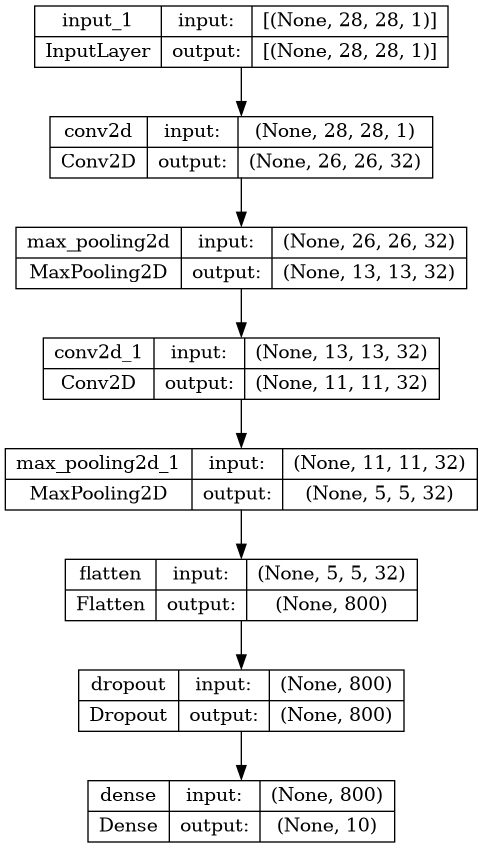

In [4]:
keras.utils.plot_model(model, show_shapes=True)

In [4]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [5]:
model.fit(X_train, y_train, batch_size=128, epochs=15, validation_data=(X_val, y_val))

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8662 - loss: 0.4338 - val_accuracy: 0.9747 - val_loss: 0.0953
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9613 - loss: 0.1283 - val_accuracy: 0.9845 - val_loss: 0.0611
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9711 - loss: 0.0945 - val_accuracy: 0.9863 - val_loss: 0.0496
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9759 - loss: 0.0776 - val_accuracy: 0.9883 - val_loss: 0.0445
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9782 - loss: 0.0708 - val_accuracy: 0.9868 - val_loss: 0.0435
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9809 - loss: 0.0618 - val_accuracy: 0.9873 - val_loss: 0.0380
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9815 - loss: 0.0596 - val_accuracy: 0.9897 - val_loss: 0.0363
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9835 - loss: 0.0531 - val_accu

In [6]:
score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.026249347254633904
Test accuracy: 0.9912999868392944


In [ ]:
model.save('baseline/MNIST_baseline_model.keras')